<a href="https://colab.research.google.com/github/exoticmga/mba_agha/blob/master/mod7_rec1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 7, Recitation 1: Introduction to Deep Learning with PyTorch and Tensorflow


In this Recitation, we will go through the basics of how to implement a simple Deep Learning model in Python, from the data preprocessing to the final evaluation and model improvements. We will also briefly explore the concept of transfer learning that we saw in Lecture 4 of this Module.

To do so, and for most of this notebook, we will work on an __image classification__ task. The goal here is to take raw images as input and have our model predict to which of several categories the image belongs to.

**IMPORTANT**

Before we start running our Colab, remember to make a copy of this notebook on your own Drive.

Another thing we'll do: we are going to use GPU to speed up our calculations! Got to __Runtime__, and click in __Change Runtime Type__. There, select __GPU__ as hardward accelerator.


**Why Change Runtime to T4 GPU?**

Google Colab provides various runtime types including none, CPU, and different GPU options. The T4 GPU is one of the GPU options offered by Google Colab for accelerating computational tasks. Switching the runtime to a T4 GPU (or any available GPU) is recommended for deep learning tasks because:

* Speed: GPUs can perform parallel operations on multiple data points simultaneously, making them significantly faster than CPUs for tasks like training neural networks, which involve a lot of matrix multiplications and additions.
* Efficiency: Training deep learning models on large datasets can be time-consuming and computationally expensive on CPUs. GPUs can reduce training time from days to hours or even minutes.

### Pytorch vs Tensorflow

PyTorch and TensorFlow are the two most widely used deep learning frameworks. Both support building, training, and deploying neural networks, and offer tools for tasks like computer vision, NLP, and transfer learning.

Typically, people use PyTorch for custom research and debugging, since it allows for more flexibility in the different architectures, and TensorFlow for fast prototyping and scalable deployment.

In this Recitation, we are going to cover both!


# Importing libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary

import sklearn.metrics as metrics
import itertools
from tqdm import tqdm



# Loading the CIFAR-10 Dataset

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is a dataset of 60,000 32×32 color images in 10 classes, with 6,000 images per class. The dataset is divided into 50,000 training images and 10,000 test images.

Each image belongs to one of ten object categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. CIFAR-10 is widely used in machine learning and computer vision as a benchmark for evaluating image classification algorithms. Its small image size and diverse categories make it suitable for testing a range of deep learning models—from simple convolutional networks to more complex architectures—while still posing a non-trivial challenge.

### The basics of data loading for Deep Learning with PyTorch

***Data Preparation in PyTorch: Transformations, Train-Test Splits, and DataLoaders***

When it comes to machine learning and deep learning, preparing your dataset correctly is crucial. This process involves several key steps: applying transformations, splitting the dataset into training and test sets, and efficiently batching the data for processing using DataLoaders. Let's explore these concepts and their significance.

**Transformations**

Transformations are operations applied to data before it is used for training. These steps are essential for preprocessing the data, making it more suitable for training neural networks.


*   **Normalization**: Adjusts the data scale to a mean and standard deviation that are more suitable for the models, often scaling image pixel values to a range like [0, 1] or [-1, 1].
*   **Conversion**: Changes the data type, such as converting images from PIL format to PyTorch tensors, facilitating operations with deep learning models.
*   **Augmentation**: Increases the dataset size artificially by applying various transformations (e.g., rotations, flipping) to existing data, enhancing model robustness.


**Train-Test Sets**

Splitting the dataset into training and test sets is standard practice in machine learning:

* **Training Set**: Used to train the model, allowing it to learn from this data.

* **Test Set**: Used to evaluate the model's performance, providing an unbiased assessment. It's crucial for testing the model's ability to generalize to new, unseen data.

**DataLoader**

The DataLoader class in PyTorch simplifies data loading, offering several features:

* **Batching**: Divides the data into batches, speeding up training and making it feasible to work with large datasets. The batch size is a crucial hyperparameter that determines the number of training examples used in one iteration. It affects memory usage, training speed, and model performance. A large batch size tends to produce smoother gradient estimates, which can lead the optimizer to converge quickly but potentially to sharp or suboptimal local minima, as the loss surface appears flatter. In contrast, a small batch size introduces more noise in the gradient updates, which can help escape local minima but may also lead to unstable or slow convergence. Selecting an appropriate batch size is important to balance convergence stability and the ability to generalize.
So a good batch size may take some trial and error to find!

* **Shuffling**: Randomizes the data order, reducing overfitting risk by preventing the model from memorizing the data sequence.

* **Parallelism**: Speeds up data loading by using multiple subprocesses.

* **Customization**: Allows for custom data loading logic, such as special batching or sampling strategies.

In [ ]:
# Transformations
transform = transforms.Compose(
    [transforms.ToTensor() # Converts a PIL.Image or numpy.ndarray with uint8 values in [0, 255] to a torch.FloatTensor with values in [0.0, 1.0]
     ])

# Loading the dataset
train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# Split the dataset (e.g., 80% for training, 20% for testing)
train_size = int(0.8 * len(train_set))
eval_size = len(train_set) - train_size
train_set, eval_set = torch.utils.data.random_split(train_set, [train_size, eval_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 32

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
eval_loader = DataLoader(eval_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


### For more details about the functions above:

```transforms.Compose```: This is a function from the torchvision library that chains together multiple image transformations. The transformations are applied in the sequence they are provided.

```transforms.ToTensor()```: Converts a PIL Image or a NumPy array into a PyTorch tensor. It changes the shape from HxWxC to CxHxW (Height x Width x Channels to Channels x Height x Width) and scales the image's intensity values from [0, 255] to [0.0, 1.0].

```transforms.Normalize((0.5,), (0.5,))```: Normalizes the tensor with a mean and standard deviation. Since the images are grayscale, a single mean and standard deviation are provided. This normalization shifts the intensity values to have a mean of 0.5 and a standard deviation of 0.5. After applying this normalization, the intensity values will range from -1.0 to 1.0. For the simple models we are going to train, we don't need this extra normalization.

```torchvision.datasets.CIFAR10```: Loads the CIFAR-10 dataset. This class is part of the `torchvision.datasets` module. CIFAR-10 is a collection of 60,000 32×32 color images across 10 categories, designed as a benchmark for evaluating image classification algorithms on small, diverse natural images. Since the images are colored, they are represented with 3 different color channels (RGB) and the dimension of each image is 3x32x32.


```root='./data'```: Specifies the directory where the dataset will be stored. If the dataset is not present in this directory, it will be downloaded.

```train=True```: Indicates that the training dataset should be loaded. If set to False, the test dataset would be loaded instead.

```download=True```: If the dataset is not available in the root directory, setting this to True will download it from the internet.

```transform=transform```: Applies the previously defined transformations to each image in the dataset.

```DataLoader```: Wraps the dataset and provides an iterable over the dataset. It supports automatic batching, sampling, shuffling, and multiprocess data loading.

```train_set```: The dataset to load data from.

```batch_size=32``` The number of samples to load in each batch. This means that each iteration over the DataLoader will return a batch of 32 images and their corresponding labels.

```shuffle=True```: Shuffles the dataset at every epoch to reduce model overfitting and improve model generalization.

### Understanding and Visualizing the data

In [ ]:
# Print the first 10 labels
print("First 10 labels:", test_set.targets[:10])

First 10 labels: [3, 8, 8, 0, 6, 6, 1, 6, 3, 1]


**What do these numbers mean?**

This is what each number 0-9 corresponds to:

| Label  | Description  |
|---|---|
|  0 | Airplane  |
|  1 |  Automobile |
|  2 |   Bird |
|  3 |  Cat |
|  4 |  Deer |
|  5 |  Dog |
|  6 |   Frog |
|  7 |  Horse |
|  8 |   Ship |
|  9 |  Track |

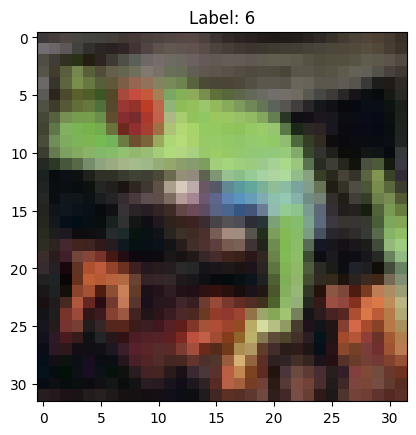

In [ ]:
# Display a raw image

# Get a sample image and its label
sample_image, sample_label = train_set[0]

# Display the image as grayscale
plt.imshow(sample_image.squeeze().permute(1, 2, 0).numpy())
plt.title(f"Label: {sample_label}")
plt.show()

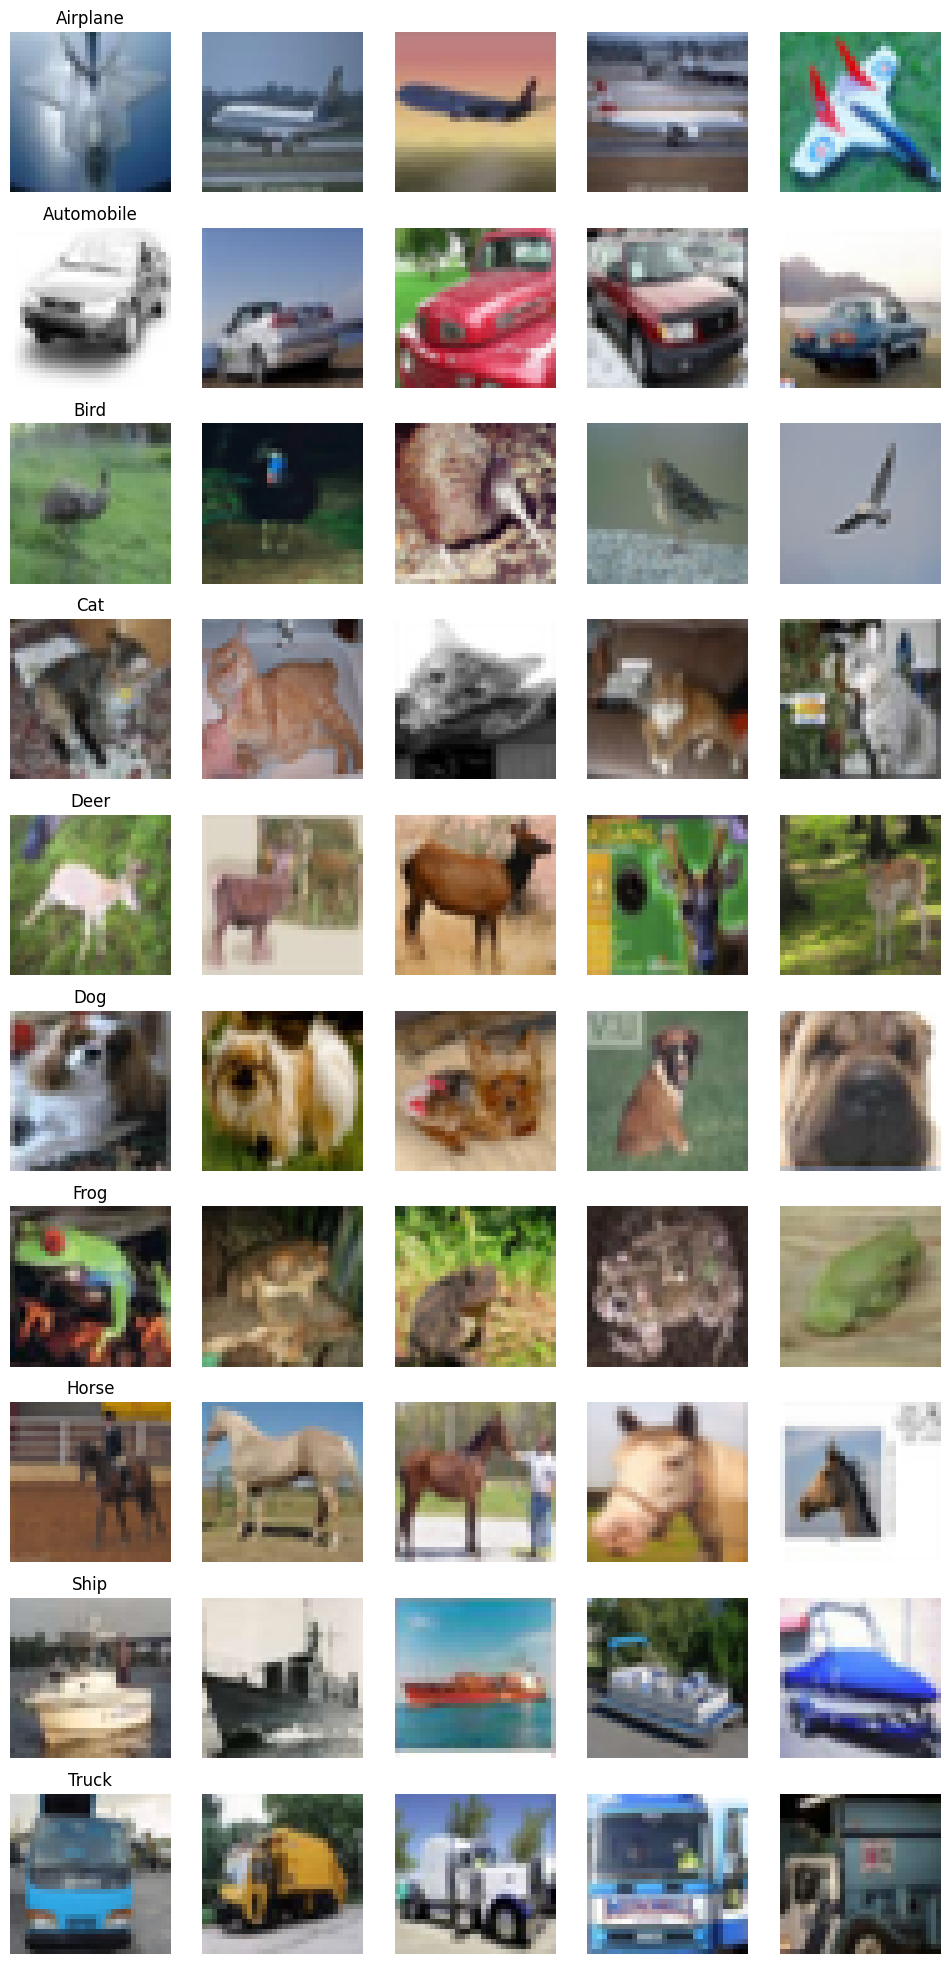

In [ ]:
# Create the label lookup table
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def show_images_by_class(dataset, num_images=5):
    fig, axs = plt.subplots(10, num_images, figsize=(12, 25))
    class_counts = {i: 0 for i in range(10)}

    for image, label in dataset:
        if class_counts[label] < num_images:
            row = label  # Class index determines the row
            col = class_counts[label]  # Column within the row
            axs[row, col].imshow(image.squeeze().permute(1,2,0).numpy(), cmap='gray')
            axs[row, col].axis('off')

            # Set title as the class label on the first image of each row
            if col == 0:
                axs[row, col].set_title(classes[label], size='large')

            class_counts[label] += 1

    plt.show()

# Assuming 'train_set' is already loaded with necessary transforms
show_images_by_class(train_set)


# Defining the Neural Network

The first step is to create the neural network architecture.

**PyTorch and ```nn.Module```**: PyTorch is a leading deep learning library prized for its flexibility and dynamic computation graphs. The ```nn.Module``` class is the cornerstone of building neural networks in PyTorch, providing the structure for layers and the forward propagation logic.

**Input and Output**: We're working with images of size 3x32x32 pixels here. The ```Linear``` layer expects a flat input, hence the ```nn.Flatten``` operation.  The final output has 10 units because we're performing a 10-class classification task.

**Linear Layers ```nn.Linear```**: Linear layers perform basic matrix multiplication and addition (followed by a bias term) to transform the input into a different representational space.

**ReLU Activation ```nn.ReLU```**: The ReLU (Rectified Linear Unit) is a popular non-linear activation function crucial for preventing the vanishing gradient problem in deep networks. It simply sets negative values to zero.

**Sequential ```nn.Sequential```**: PyTorch's ```nn.Sequential``` is a container that helps you chain layers and activation functions neatly.

In [ ]:
class NeuralNet(nn.Module):
  def __init__(self):
    super(NeuralNet, self).__init__()  # Initialize base class (nn.Module)

    self.flatten = nn.Flatten()  # Flattens multidimensional input into a single dimension

    self.linear_relu_stack = nn.Sequential(
      nn.Linear(3*32*32, 512),  # First linear layer (input: 3x32x32, output: 512)
      nn.ReLU(),               # ReLU activation (introduces non-linearity)
      nn.Linear(512, 10),      # Second linear layer (maps to 10 output classes)
    )

  def forward(self, x):
    x = self.flatten(x)            # Flatten the input image data
    logits = self.linear_relu_stack(x)  # Pass through linear layers and activation
    return logits                   # Raw output scores for each class


## Initialize the Network and Define Loss Function and Optimizer

The next lines complete the core setup for training your feedforward neural network. You will now have:

* A Neural Network (```net```): Contains the structure of your model.
* A Loss Function (```criterion```): Defines how to measure the error of your predictions.
* An Optimizer (```optimizer```): Determines how to update the network's weights to minimize the loss.

In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Create an instance of our neural network model
net = NeuralNet().to(device)

# Specify the input shape ([batch_size, 1, 28, 28] for images)
summary(net, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 512]       1,573,376
              ReLU-3                  [-1, 512]               0
            Linear-4                   [-1, 10]           5,130
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 6.02
Estimated Total Size (MB): 6.06
----------------------------------------------------------------


In [ ]:
# Define the loss function (cross-entropy is common for classification)
criterion = nn.CrossEntropyLoss()

# Set up the optimizer (SGD with a learning rate of 0.001 and momentum)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Details about the code above:

*  `nn.CrossEntropyLoss` is a standard loss function for classification tasks. It gauges the "discrepancy"  between the model's predictions and the true labels.

* **Stochastic Gradient Descent (```SGD```):** A widely used optimization algorithm responsible for tuning the model's weights and biases.

* **```net.parameters()```:** Specifies the trainable model parameters for the optimizer.

* **Learning Rate (```lr=0.001```):**  A hyperparameter governing the size of the updates during training.

* **Momentum (```momentum=0.9```):**   A technique to boost SGD's convergence and reduce oscillations.


# Training the Network

**Key Points about the Training Loop**

* **Epoch:** A complete iteration over the entire training dataset.

* **Mini-batch:** Training datasets are frequently subdivided into smaller 'mini-batches' to improve computational efficiency and optimization.

* **Gradient Reset:** Calling `optimizer.zero_grad()` clears out accumulated gradients from previous mini-batches. This ensures gradient calculations accurately reflect the current batch.

* **Forward pass:** The input passes through the network and the outputs are collected.

* **Loss Computation:** The cross-entropy loss (or a similar function) quantifies the difference between the network's predicted outputs and the target labels.

* **Backpropagation:** Computes gradients of the loss function with respect to all the model's parameters (weights and biases), providing directions for their updates.

* **Optimizer Update:** The optimizer (like SGD) utilizes the calculated gradients to adjust the model's parameters with the goal of minimizing the loss.

* **Logging:** Regularly tracking and visualizing the running loss (averaged over mini-batches) offers crucial insights into the model's training progress.


In [ ]:
def train_model(net, train_loader, eval_loader, optimizer, criterion, num_epoch = 2):
    """
    Trains a neural network model and evaluates on a test set after each epoch.

    Parameters:
    - net: The neural network to train.
    - train_loader: DataLoader for the training data.
    - test_loader: DataLoader for the evaluation data.
    - optimizer: Optimization algorithm.
    - criterion: Loss function.
    """
    for epoch in range(num_epoch):
        # Training Phase
        running_loss = 0.0
        for i, data in enumerate(tqdm(train_loader)):  # Iterate over mini-batches of data

            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data  # Unpack the batch's input images and their labels

            # move to GPU
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()  # Reset accumulated gradients from previous steps

            # forward + backward + optimize
            outputs = net(inputs)  # Forward pass: Compute predictions
            loss = criterion(outputs, labels)  # Calculate the loss value
            loss.backward()  # Backpropagation: Compute gradients of the loss
            optimizer.step()  # Update model parameters based on the gradients

            running_loss += loss.item()  # Add loss of this mini-batch to running total

        # Evaluation Phase
        correct = 0
        total = 0
        with torch.no_grad():  # Disable gradient calculation during evaluation
            for data in tqdm(eval_loader):
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f'Epoch {epoch+1} Accuracy: {accuracy}%')

# Example Usage (Assuming you have your dataset/models set up)
train_model(net, train_loader, eval_loader, optimizer, criterion, num_epoch = 5)


100%|██████████| 313/313 [00:01<00:00, 207.02it/s]


Epoch 1 Accuracy: 35.07%


100%|██████████| 313/313 [00:01<00:00, 221.71it/s]


Epoch 2 Accuracy: 39.73%


100%|██████████| 313/313 [00:01<00:00, 230.59it/s]


Epoch 3 Accuracy: 40.51%


100%|██████████| 313/313 [00:03<00:00, 101.21it/s]


Epoch 4 Accuracy: 42.61%


100%|██████████| 313/313 [00:01<00:00, 216.80it/s]

Epoch 5 Accuracy: 44.43%


# Testing the Network on the Test Data

In [ ]:
def test_model(net, test_loader):
    """
    Tests a neural network model's performance on the test dataset.

    Parameters:
    - net: The neural network to test.
    - test_loader: DataLoader for the test data.
    """
    correct = 0  # Initialize a counter for correct predictions
    total = 0  # Initialize a counter for the total number of test images

    # Ensure the model is in evaluation mode
    net.eval()

    with torch.no_grad():  # Temporarily disable gradient calculation for evaluation
        for data in test_loader:
            images, labels = data  # Get a batch of test images and their labels

            # move to GPU
            images, labels = images.to(device), labels.to(device)

            outputs = net(images)  # Pass images through the network for predictions
            _, predicted = torch.max(outputs.data, 1)  # Get index of the highest probability class
            total += labels.size(0)  # Update the total image count
            correct += (predicted == labels).sum().item()  # Increment correct count if predictions match

    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')

# Now call the function with the appropriate parameters
test_model(net, test_loader)

Accuracy of the network on the 10000 test images: 44.86 %


### (For more explanations) **Evaluating Model Performance**


This code snippet above outlines the steps involved in calculating your trained neural network's accuracy on the test dataset. Here's the breakdown:

* **Counters:** `correct`  tracks correctly classified images, `total` maintains the overall number of test images.

* **torch.no_grad():** Disables gradient computations during evaluation. This saves memory and computation as gradients aren't required for updating weights.

* **Iterating Over Test Data:** The loop processes the test data in mini-batches provided by the `test_loader`.

* **Predictions:** `net(images)` feeds the images to the model obtaining prediction scores (`outputs`).

* **Most Likely Class:**  `torch.max(outputs.data, 1)` obtains the class index with the highest prediction score for each image.

* **Accuracy Tracking:**  
     * `total += labels.size(0)`:  Tracks the total number of images in the test set.

     * `correct += (predicted == labels).sum().item()`: Increments the `correct` counter if the predicted class matches the ground-truth label.

* **Printing Accuracy:**   Calculates and prints the overall accuracy percentage on the test dataset.


### Understanding the model's errors

In machine learning, particularly in the domain of image classification, evaluating a model's performance goes beyond simply looking at the overall accuracy. Understanding the specific types of errors a model makes can be crucial for improving its design and tuning its parameters. This detailed analysis involves two key components: constructing a confusion matrix and visualizing misclassified examples.

The **confusion matrix** is a powerful tool for summarizing the performance of a classification algorithm. It allows us to see not just the errors overall, but specifically where the model is getting confused. For instance, it might reveal that the model frequently misclassifies 'Cats' as 'Dogs', indicating that the model struggles to differentiate between these similar categories. This insight can guide us to adjust the training process, perhaps by providing more training data for these classes or tweaking the model architecture.

**Visualizing misclassified examples**, on the other hand, offers a direct look into the instances where the model's predictions diverge from the actual labels. By examining these cases, we can gain intuition about what features the model might be paying attention to and where it might be getting misled. This can inspire new preprocessing steps, feature engineering, or even corrections to the dataset itself if mislabeled examples are found.

Together, these analyses provide a holistic view of a model's performance, highlighting strengths and pinpointing specific weaknesses. This is essential for iterative model improvement, allowing developers and researchers to make informed decisions about where to focus their efforts for enhancement. The following code snippets encapsulate the functionality to perform these analyses efficiently, offering a modular and reusable way to apply these insights across different models and datasets.

In [ ]:
def compute_confusion_matrix(net, test_loader, classes):
    """
    Computes the confusion matrix for the given model and test data.

    Parameters:
    - net: Trained neural network model.
    - test_loader: DataLoader for the test dataset.
    - classes: List of class names.
    """
    all_labels = []
    all_predicted = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.detach().cpu().numpy())  # Convert to numpy array before extending
            all_predicted.extend(predicted.detach().cpu().numpy())  # Convert to numpy array before extending

    cm = metrics.confusion_matrix(all_labels, all_predicted)
    return cm

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots the confusion matrix.

    Parameters:
    - cm: Confusion matrix array.
    - classes: List of class names.
    - title: Title for the plot.
    - cmap: Colormap for the plot.
    """
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


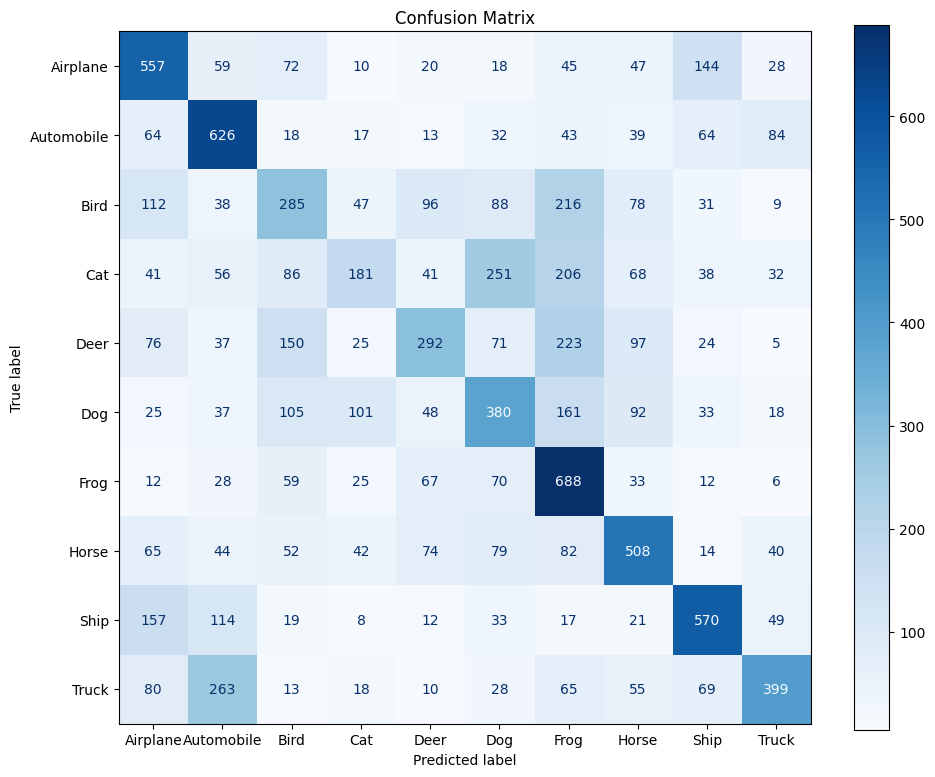

In [ ]:
# Ensure net, test_loader, and classes are defined and initialized before calling these functions
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
cm = compute_confusion_matrix(net, test_loader, classes)
plot_confusion_matrix(cm, classes)

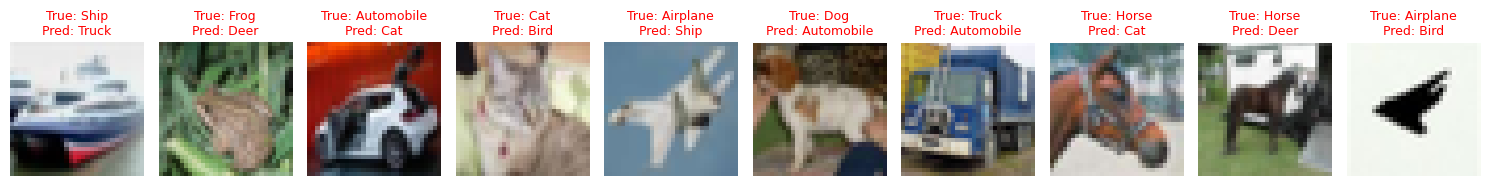

In [ ]:
def visualize_misclassified_examples_colored(net, test_loader, classes, num_images=10):
    """
    Visualizes a number of misclassified examples, with the true label in green and the predicted label in red.

    Parameters:
    - net: Trained neural network model.
    - test_loader: DataLoader for the test dataset.
    - classes: List of class names.
    - num_images: Number of misclassified images to display.
    """
    misclassified = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            misclassified += [(images[i], labels[i].item(), predicted[i].item()) for i in range(images.size(0)) if labels[i] != predicted[i]]
            if len(misclassified) >= num_images:
                break

    fig, axs = plt.subplots(1, num_images, figsize=(15, 4), squeeze=False)
    for i, (image, true_label, pred_label) in enumerate(misclassified[:num_images]):
        axs[0, i].imshow(image.squeeze().permute(1,2,0).detach().cpu().numpy(), cmap='gray')
        axs[0, i].set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}', fontsize=9)
        # Apply colors to titles
        axs[0, i].title.set_color('red')
        axs[0, i].axis('off')
    plt.tight_layout()
    plt.show()

# Ensure net, test_loader, and classes are defined and initialized before calling this function
visualize_misclassified_examples_colored(net, test_loader, classes, num_images=10)


Overall, we observe that the model's performance is poor. This indicates that using Feedforward Neural Networks to classify images is not optimal; we are now going to explore how to use Convolutional Neural Networks to solve the same problem.

# Introduction to Convolutional Neural Networks

When transitioning from implementing a Feedforward Neural Network (FNN) to a Convolutional Neural Network (CNN) in PyTorch, several key changes and concepts are introduced:

**Introduction of convolution layers**

In CNNs, we use convolutional layers (`torch.nn.Conv2d`) instead of fully connected layers as in FNNs. Convolutional layers apply a convolution operation to the input, capturing spatial hierarchies in the data. This makes CNNs particularly well-suited for processing images and other types of spatial data.

**Utilization of Pooling Layers**

Pooling layers (such as `torch.nn.MaxPool2d`) are used in CNNs to reduce the spatial dimensions of the output from the convolutional layers. Pooling helps in reducing the number of parameters, computation, and helps in achieving spatial invariance to some extent.

**Flattening the Output for Fully Connected Layers**

After several convolutional and pooling layers, the output is flattened (using `torch.flatten` or the `view` method) to feed into fully connected layers. This step is necessary to transition from the spatial representation of data to a format suitable for classification or regression.

**Adjusting to Input Shape Requirements**

CNNs require the input data to have a specific shape, typically `[batch_size, channels, height, width]`, meaning that preprocessing of data might be necessary to reshape inputs accordingly.

**Parameter Sharing and Local Connectivity**

Convolutional layers share parameters across different parts of the input, significantly reducing the model size compared to FNNs. This approach, combined with local connectivity (processing small, local areas of the input), allows CNNs to be more efficient and effective for image data.

**Increased Depth with Many Layers**

CNNs often utilize deeper architectures than FNNs because the convolutional and pooling layers allow for efficient processing of large inputs such as images. The depth of CNNs enables them to capture complex patterns with a hierarchical structure.

Let's see how to create a CNN class.

In [ ]:
class CNN(nn.Module):
  def __init__(self):
      super(CNN, self).__init__()
      self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
      self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
      self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

      self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
      self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

      self.fc1 = nn.Linear(256 * 8 * 8, 512)
      self.fc2 = nn.Linear(512, 10)

  def forward(self, x):
      x = F.relu(self.conv1(x))      # 32x32 → 32x32
      x = F.relu(self.conv2(x))      # 32x32 → 32x32
      x = self.pool(x)               # 32x32 → 16x16
      x = F.relu(self.conv3(x))      # 16x16 → 16x16
      x = F.relu(self.conv4(x))      # 16x16 → 16x16
      x = self.pool(x)               # 16x16 → 8x8
      x = x.view(-1, 256 * 8 * 8)
      x = F.relu(self.fc1(x))
      x = self.fc2(x)
      return x

Nothing changes for the rest of the code!

In [ ]:
# Batch size, optimizers, and other hyperparameters remain as you defined them earlier.

# Create an instance of our CNN model
net = CNN().to(device)

# Continue using CrossEntropyLoss for the classification
criterion = nn.CrossEntropyLoss()

# Using Adam optimizer with the CNN, including weight decay for regularization
optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)

# Adjusted number of epochs for training the CNN model
train_model(net, train_loader, eval_loader, optimizer, criterion, num_epoch=5)

test_model(net, test_loader)

100%|██████████| 313/313 [00:02<00:00, 117.99it/s]


Epoch 1 Accuracy: 60.91%


100%|██████████| 313/313 [00:02<00:00, 116.60it/s]


Epoch 2 Accuracy: 70.02%


100%|██████████| 313/313 [00:02<00:00, 116.88it/s]


Epoch 3 Accuracy: 73.45%


100%|██████████| 313/313 [00:02<00:00, 112.84it/s]


Epoch 4 Accuracy: 72.87%


100%|██████████| 313/313 [00:02<00:00, 107.96it/s]


Epoch 5 Accuracy: 73.94%
Accuracy of the network on the 10000 test images: 73.1 %


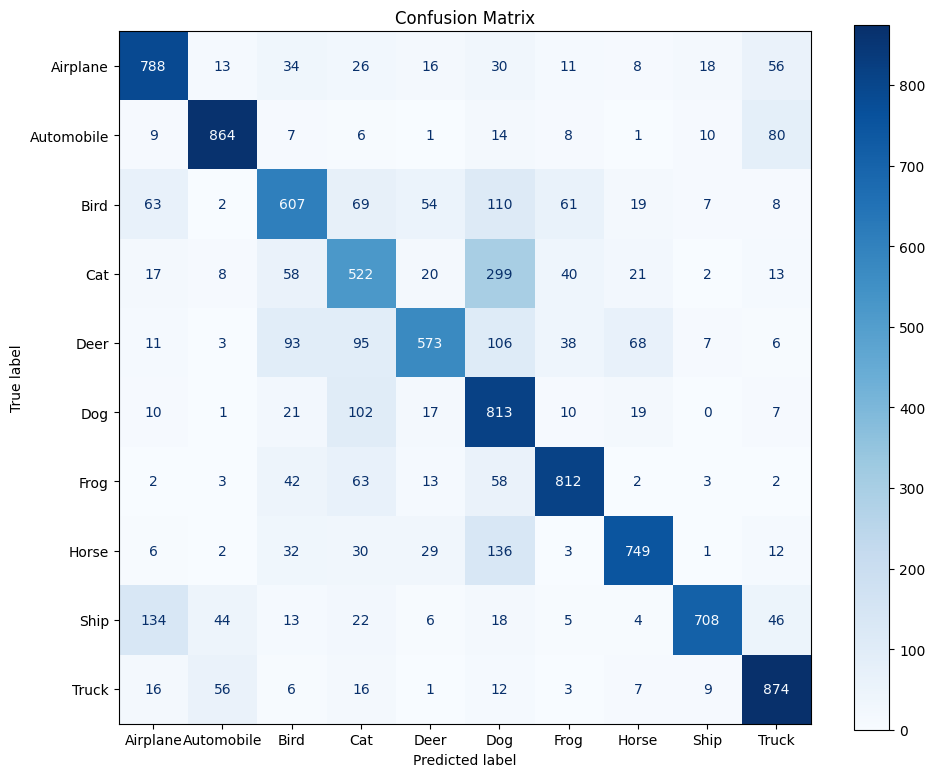

In [ ]:
# Ensure net, test_loader, and classes are defined and initialized before calling these functions
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
cm = compute_confusion_matrix(net, test_loader, classes)
plot_confusion_matrix(cm, classes)

Here are some tips to modify the code to improve performance.

* **Architecture**
    * **Deeper Layers:**  Experiment by adding more linear layers to extract more complex features.
    * **Regularization:** Incorporate Dropout or L1/L2 weight regularization to combat overfitting.

* **Hyperparameters:**
    * **Learning Rate:**  Explore various learning rates and optimization algorithms (Adam, RMSprop, SGD with momentum, etc).
    * **Batch Size:** Tweak the batch size to influence gradient updates and convergence.

* **Training**
    * **Longer Training:** Increase the number of epochs (iterations over the dataset).
    * **Early Stopping:** Halt training if validation performance plateaus or worsens.



# Keras version

Let's implement the same approach in Keras, a high-level deep learning API integrated with TensorFlow. Keras simplifies many operations, making it easier to define, train, and evaluate models compared to PyTorch. Below is the complete Keras implementation with explanations, highlighting how it reduces complexity while achieving similar results.



In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, ReLU, Input, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD

ds_name = 'cifar10'

# Step 1: Load CIFAR-10
(train_ds, val_ds), info = tfds.load(ds_name,
                    split=["train[:80%]", "train[80%:]"],
                    batch_size = 32,
                    as_supervised=True,
                    with_info = True
                    )

test_ds, info_test = tfds.load(ds_name,
                    split="test",
                    batch_size = 32,
                    as_supervised=True,
                    with_info = True
                    )

# Step 2: Normalize
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_ds_processed = train_ds.map(preprocess).shuffle(len(train_ds))
val_ds_processed = val_ds.map(preprocess)
test_ds_processed = test_ds.map(preprocess)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.AWS8A9_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.AWS8A9_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


After loading the data and preprocessing, we are first training a simple FeedForward Neural Network.

In [ ]:
# Step 3: Define simple dense model
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(512),
    ReLU(),
    Dense(10, activation='softmax')
])

# Step 4: Compile and train
model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds_processed, epochs=5, validation_data=val_ds_processed)

# Step 5: Evaluate
test_loss, test_acc = model.evaluate(test_ds_processed, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2746 - loss: 1.9888 - val_accuracy: 0.3509 - val_loss: 1.8089
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3560 - loss: 1.7922 - val_accuracy: 0.3765 - val_loss: 1.7461
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3735 - loss: 1.7404 - val_accuracy: 0.3789 - val_loss: 1.7234
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3958 - loss: 1.6907 - val_accuracy: 0.4169 - val_loss: 1.6405
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4087 - loss: 1.6406 - val_accuracy: 0.4221 - val_loss: 1.6276
Test Accuracy: 41.02%


Similarly to before, we observe that the performance is low. We are now going to build a Convolutional Neural Network.

In [ ]:
model = Sequential([
    # Input and first conv block
    Input((32, 32, 3)),
    Conv2D(64, kernel_size=3, padding='same'),
    ReLU(),

    Conv2D(128, kernel_size=3, padding='same'),
    ReLU(),

    MaxPooling2D(pool_size=2, strides=2),  # 32x32 → 16x16

    # Second conv block
    Conv2D(256, kernel_size=3, padding='same'),
    ReLU(),

    Conv2D(256, kernel_size=3, padding='same'),
    ReLU(),

    MaxPooling2D(pool_size=2, strides=2),  # 16x16 → 8x8

    # Fully connected layers
    Flatten(),                            # 8x8x256 = 16384
    Dense(512),
    ReLU(),
    Dense(10, activation='softmax')  # Logits output (no activation)
])


# Step 4: Compile and train
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(train_ds_processed, epochs=5, validation_data=val_ds_processed)

# Step 5: Evaluate
test_loss, test_acc = model.evaluate(test_ds_processed, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.3874 - loss: 1.6613 - val_accuracy: 0.6267 - val_loss: 1.0420
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.6695 - loss: 0.9308 - val_accuracy: 0.7121 - val_loss: 0.8090
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7634 - loss: 0.6764 - val_accuracy: 0.7385 - val_loss: 0.7490
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8314 - loss: 0.4785 - val_accuracy: 0.7421 - val_loss: 0.7698
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8925 - loss: 0.3088 - val_accuracy: 0.7420 - val_loss: 0.8899
Test Accuracy: 73.59%


# Transfer Learning

## Introduction

**Transfer learning** consists of taking features learned on one problem, and
leveraging them on a new, similar problem. For instance, features from a model that has
learned to identify animals in general may be useful to kick-start a model meant to identify birds only.

Transfer learning can be especially useful for tasks where your dataset has too little data to train a full-scale model from scratch.

The most common incarnation of transfer learning in the context of deep learning is the following workflow:

1. Take layers from a previously trained model.
2. Freeze them, so as to avoid destroying any of the information they contain during future training rounds.
3. Add some new, trainable layers on top of the frozen layers. They will learn to turn the old features into predictions on a  new dataset.
4. Train the new layers on your dataset.

A last, optional step, is **fine-tuning**, which consists of unfreezing the entire model you obtained above (or part of it), and re-training it on the new data with a very low learning rate. This can potentially achieve meaningful improvements, by incrementally adapting the pretrained features to the new data.

## The typical transfer-learning workflow

This leads us to how a typical transfer learning workflow can be implemented in Keras:

1. Instantiate a base model and load pre-trained weights into it.
2. Freeze all layers in the base model by setting `trainable = False`.
3. Create a new model on top of the output of one (or several) layers from the base
 model.
4. Train your new model on your new dataset.

Here is how the workflow looks like in Keras:

First, instantiate a base model with pre-trained weights.

```python
base_model = keras.applications.<MODELNAME>(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(<height>, <width>, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.
```

Then, freeze the base model.

```python
base_model.trainable = False
```

Create a new model on top.

```python
inputs = keras.Input(shape=(<height>, <width>, 3))
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.
x = base_model(inputs, training=False)
# Convert features of shape `base_model.output_shape[1:]` to vectors
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
# You can change the value to any number of your choice, depending on how many classes you have.
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
```

Train the model on new data.

```python
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])
model.fit(new_dataset, epochs=20, callbacks=..., validation_data=...)
```

## Create the base model from the pre-trained convnets
We will create the base model from the **MobileNet V2** model developed at Google, which runs very fast as it was built for running on mobile devices. This is pre-trained on the ImageNet dataset, a large dataset consisting of 1.4M images and 1000 classes. ImageNet is a research training dataset with a wide variety of categories like `jackfruit`, `goldfish`, or `forklift`.

First, we need to pick which layer of MobileNet V2 we will use for feature extraction. The very last classification layer (on "top", as most diagrams of machine learning models go from bottom to top) is not very useful. Instead, we will follow the common practice to depend on the very last layer before the flatten operation. This layer is called the "bottleneck layer". The bottleneck layer features retain more generality as compared to the final/top layer.

First, we instantiate a MobileNet V2 model pre-loaded with weights trained on ImageNet. By specifying the `include_top=False` argument, we load a network that doesn't include the classification layers at the top, which is ideal for feature extraction.

When we use a pretrained model, we should careful to preprocess the data the way it expects it. In particular, check:
- if we need to standardize/normalize differently (in general we standardize using the ImageNet means and stds)
- if we need to reshape the picture (typically many models use the 224x224 size, but others can expect larger, like Xception with 299x299)
- in short, we should check the `tf` documentation of the model you want to use.

In [ ]:
# To work properly, the pretrained network expects an image of about the same size it was trained on.
# CIFAR10 is of shape 32x32x3, while ImageNet is generally reshaped as 224x224x3.

# We chose 128 as the height and width of the images
SIZE = 128

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(SIZE, SIZE, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = tf.keras.Input(shape=(32, 32, 3))

resize_layer = tf.keras.layers.Resizing(SIZE, SIZE)
x = resize_layer(inputs) #Necessary to resize each image


# Pre-trained network weights often require that input be scaled
# from (0, 255) to a range of (-1., +1.). the rescaling layer
# outputs: `(inputs * scale) + offset`
scale_layer = tf.keras.applications.mobilenet_v2.preprocess_input
x = scale_layer(x)

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)

# We add a GlobalAveragePool layer.
# It takes the average of each feature map (across height and width), producing a single vector per image.
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
x = global_average_layer(x)

# We add a Dropout Layer, to reduce overfitting.
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(10, activation = "softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

epochs = 5
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

# Step 5: Evaluate
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.7168 - loss: 0.8519 - val_accuracy: 0.8359 - val_loss: 0.4753
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8361 - loss: 0.4796 - val_accuracy: 0.8477 - val_loss: 0.4457
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8465 - loss: 0.4515 - val_accuracy: 0.8485 - val_loss: 0.4476
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8509 - loss: 0.4380 - val_accuracy: 0.8482 - val_loss: 0.4489
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8550 - loss: 0.4283 - val_accuracy: 0.8524 - val_loss: 0.4387
Test Accuracy: 84.31%


We observe that the performance improved even more. Can we do even better?

One option is to unfreeze some of the layers in the pretrained network and fine-tune them for a few additional epochs. This allows the model to adapt its learned features to the new dataset. However, it's important to keep the number of fine-tuning epochs small — MobileNetV2 has a large number of parameters, and extended training can lead to overfitting on the new dataset. Worse, it may cause the model to forget the general features it learned from ImageNet, which defeats the purpose of transfer learning.

In [ ]:
base_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 50

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable =  False

Number of layers in the base model:  154


In [ ]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [ ]:
fine_tune_epochs = 2
total_epochs =  epochs + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1] + 1,
                         validation_data=val_ds)

# Step 5: Evaluate
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Epoch 6/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 30ms/step - accuracy: 0.8214 - loss: 0.6120 - val_accuracy: 0.8910 - val_loss: 0.3595
Epoch 7/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.9520 - loss: 0.1391 - val_accuracy: 0.9069 - val_loss: 0.3285
Test Accuracy: 90.15%


## Key Takeaways

- Fully connected networks (FFNs) are not well-suited for image data. They ignore spatial structure and typically underperform on image classification tasks like CIFAR-10.

- Convolutional Neural Networks (CNNs) significantly improve performance by capturing local patterns and spatial hierarchies through shared weights and local connectivity.

- Transfer learning using pretrained models like MobileNetV2 allows us to leverage features learned on large datasets (like ImageNet), often resulting in higher accuracy with fewer training epochs.

- Freezing the base of a pretrained model and training only the new classifier is a strong baseline; unfreezing top layers for fine-tuning can further improve results — but should be done carefully to avoid overfitting.

- Proper input preprocessing and normalization are critical, especially when using pretrained networks.